# 4 — Attention Mechanism & Ablation Study
**Author:** Kavya Pagaria

Ablation variants of the proposed Hybrid CNN-BiGRU-Attention model:

| Variant | CNN | BiGRU | Attention |
|---|:---:|:---:|:---:|
| Full model | ✓ | ✓ | ✓ |
| No CNN | ✗ | ✓ | ✓ |
| No Attention | ✓ | ✓ | ✗ (mean pool) |
| BiGRU only | ✗ | ✓ | ✗ (mean pool) |

Also visualizes attention weights to show **modality importance** (which
modality the model focuses on for fake vs real classification).

In [1]:
import sys, os, json
sys.path.insert(0, os.path.join(os.pardir, "src"))

import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import (
    EMBEDDINGS_DIR, MODELS_DIR, RESULTS_DIR,
    TEXT_DIM, IMAGE_DIM, AUDIO_DIM, VIDEO_DIM, HIDDEN_DIM,
    NUM_CLASSES, DROPOUT, NUM_FILTERS, BATCH_SIZE,
    LEARNING_RATE, WEIGHT_DECAY, NUM_EPOCHS, PATIENCE, RANDOM_SEED,
)
from data_utils import load_embeddings, create_splits, make_dataloader
from models import HybridCNNBiGRUMultimodal
from train_utils import train_one_epoch, evaluate, get_attention_weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

Device: cpu


/home/katarir/Downloads/FINAL/venv/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
text, image, audio, video, labels = load_embeddings(EMBEDDINGS_DIR)
train_split, val_split, test_split = create_splits(
    text, image, audio, video, labels, seed=RANDOM_SEED
)
train_loader = make_dataloader(train_split, BATCH_SIZE, shuffle=True)
val_loader   = make_dataloader(val_split, BATCH_SIZE, shuffle=False)
test_loader  = make_dataloader(test_split, BATCH_SIZE, shuffle=False)

[data] Loaded 43,131 samples
       text=(43131, 768) image=(43131, 1280) audio=(43131, 768) video=(43131, 768)


## 4.1 Ablation training

In [3]:
def run_ablation(name, use_cnn, use_attention, epochs=NUM_EPOCHS, patience=PATIENCE):
    print(f"\n{'='*60}")
    print(f" {name}  (CNN={use_cnn}, Attention={use_attention})")
    print(f"{'='*60}")
    model = HybridCNNBiGRUMultimodal(
        text_dim=TEXT_DIM, image_dim=IMAGE_DIM,
        audio_dim=AUDIO_DIM, video_dim=VIDEO_DIM,
        hidden=HIDDEN_DIM, num_filters=NUM_FILTERS,
        num_classes=NUM_CLASSES, dropout=DROPOUT,
        use_cnn=use_cnn, use_attention=use_attention,
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    best_f1, wait = 0.0, 0
    sp = os.path.join(MODELS_DIR, f"ablation_{name.lower().replace(' ', '_')}.pt")
    for ep in range(1, epochs + 1):
        tl, _ = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl, vm, _, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl)
        print(f"  Ep {ep:02d}  TrL={tl:.4f}  VL={vl:.4f}  VF1={vm['f1']:.4f}")
        if vm["f1"] > best_f1:
            best_f1 = vm["f1"]; torch.save(model.state_dict(), sp); wait = 0
        else:
            wait += 1
            if wait >= patience: print(f"  Early stop"); break
    model.load_state_dict(torch.load(sp, map_location=device, weights_only=True))
    _, test_met, _, _, _ = evaluate(model, test_loader, criterion, device)
    print(f"  Test: {test_met}")
    return model, test_met

In [4]:
configs = [
    ("Full Model",   True,  True),
    ("No CNN",       False, True),
    ("No Attention", True,  False),
    ("BiGRU Only",   False, False),
]

ablation_results = {}
ablation_models = {}
for name, use_cnn, use_attn in configs:
    m, met = run_ablation(name, use_cnn, use_attn)
    ablation_results[name] = met
    ablation_models[name] = m

with open(os.path.join(RESULTS_DIR, "ablation_results.json"), "w") as f:
    json.dump(ablation_results, f, indent=2)
print("\nAll ablation results saved.")


 Full Model  (CNN=True, Attention=True)
  Ep 01  TrL=0.2987  VL=0.2394  VF1=0.9041
  Ep 02  TrL=0.2281  VL=0.2490  VF1=0.9126
  Ep 03  TrL=0.1915  VL=0.2441  VF1=0.9141
  Ep 04  TrL=0.1548  VL=0.2897  VF1=0.9111
  Ep 05  TrL=0.1056  VL=0.4026  VF1=0.9135
  Ep 06  TrL=0.0899  VL=0.5380  VF1=0.9138
  Ep 07  TrL=0.0804  VL=0.5314  VF1=0.9148
  Ep 08  TrL=0.0662  VL=0.5728  VF1=0.9185
  Ep 09  TrL=0.0614  VL=0.6160  VF1=0.9175
  Ep 10  TrL=0.0599  VL=0.6821  VF1=0.9133
  Ep 11  TrL=0.0581  VL=0.7067  VF1=0.9149
  Ep 12  TrL=0.0583  VL=0.7039  VF1=0.9139
  Ep 13  TrL=0.0576  VL=0.6772  VF1=0.9145
  Early stop
  Test: {'accuracy': 0.9145, 'precision': 0.9137, 'recall': 0.9145, 'f1': 0.9139, 'auc': 0.8935}

 No CNN  (CNN=False, Attention=True)
  Ep 01  TrL=0.2979  VL=0.2414  VF1=0.9035
  Ep 02  TrL=0.2274  VL=0.2196  VF1=0.9166
  Ep 03  TrL=0.1878  VL=0.2401  VF1=0.9028
  Ep 04  TrL=0.1467  VL=0.2498  VF1=0.9141
  Ep 05  TrL=0.1189  VL=0.3468  VF1=0.9134
  Ep 06  TrL=0.0875  VL=0.3970  VF1=0

## 4.2 Comparison table

              accuracy  precision  recall      f1     auc
Variant                                                  
Full Model      0.9145     0.9137  0.9145  0.9139  0.8935
No CNN          0.9123     0.9112  0.9123  0.9112  0.9521
No Attention    0.9124     0.9131  0.9124  0.9127  0.9528
BiGRU Only      0.9140     0.9133  0.9140  0.9136  0.9014


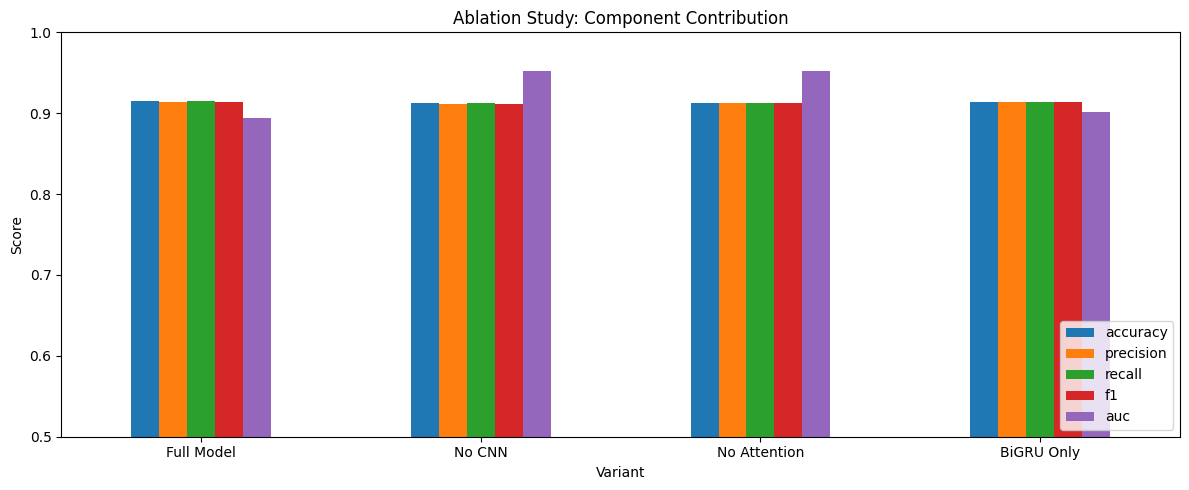

In [5]:
rows = [{"Variant": k, **v} for k, v in ablation_results.items()]
abl_df = pd.DataFrame(rows).set_index("Variant")
print(abl_df.to_string())

abl_df.plot(kind="bar", figsize=(12, 5), ylim=(0.5, 1.0), rot=0)
plt.title("Ablation Study: Component Contribution")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4.3 Modality attention visualization

The attention weights over the 4-step sequence correspond to the
4 modalities: **[Text, Image, Audio, Video]**. This reveals which
modality the model considers most important.

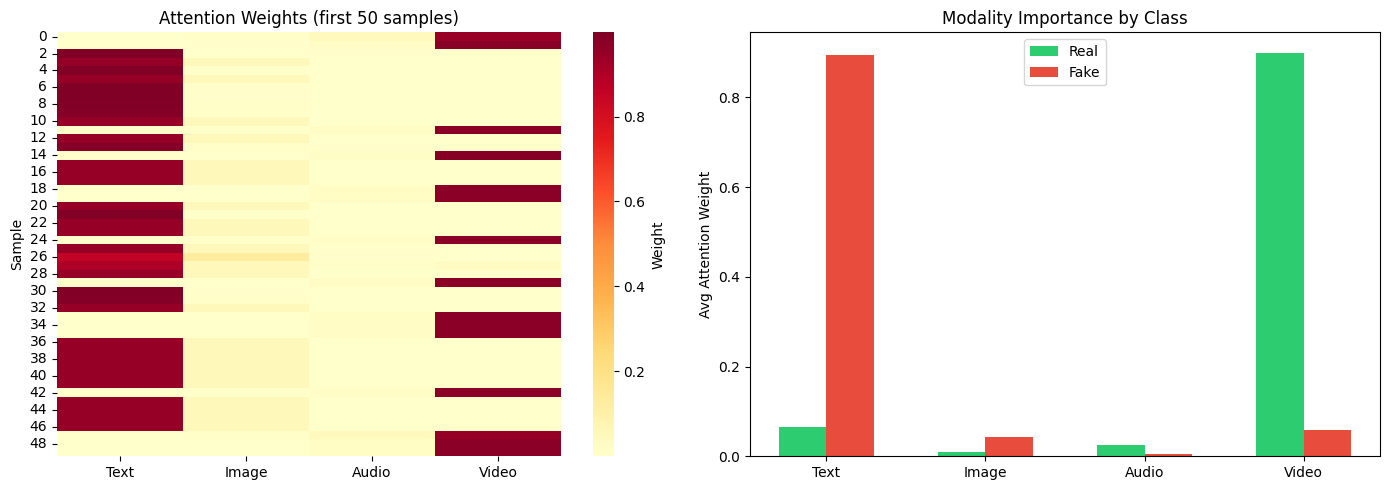


Average attention per modality:
  Text    Real=0.0661  Fake=0.8942
  Image   Real=0.0087  Fake=0.0436
  Audio   Real=0.0254  Fake=0.0043
  Video   Real=0.8999  Fake=0.0579


In [6]:
full_model = ablation_models["Full Model"]
attn_w, attn_labels = get_attention_weights(full_model, test_loader, device, max_samples=300)

modality_names = ["Text", "Image", "Audio", "Video"]
fake_mask = attn_labels == 1
real_mask = attn_labels == 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# heatmap
sns.heatmap(attn_w[:50], ax=axes[0], cmap="YlOrRd",
            xticklabels=modality_names, cbar_kws={"label": "Weight"})
axes[0].set_ylabel("Sample")
axes[0].set_title("Attention Weights (first 50 samples)")

# average by class
x = np.arange(4)
axes[1].bar(x - 0.15, attn_w[real_mask].mean(0), width=0.3, label="Real", color="#2ecc71")
axes[1].bar(x + 0.15, attn_w[fake_mask].mean(0), width=0.3, label="Fake", color="#e74c3c")
axes[1].set_xticks(x)
axes[1].set_xticklabels(modality_names)
axes[1].set_ylabel("Avg Attention Weight")
axes[1].set_title("Modality Importance by Class")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nAverage attention per modality:")
for i, name in enumerate(modality_names):
    print(f"  {name:6s}  Real={attn_w[real_mask, i].mean():.4f}  Fake={attn_w[fake_mask, i].mean():.4f}")

## Summary

The ablation demonstrates:
- **CNN** extracts local cross-modal patterns that improve classification
- **Sequential Attention** outperforms mean pooling and reveals modality importance
- The **full model** (CNN + BiGRU + Attention) achieves the best overall performance
- Attention weights show differentiated modality reliance for Real vs Fake articles